# SPRINT 11

Aquesta pràctica integra l'ús de Python amb les llibreries Pandas, Matplotlib, Seaborn o Plotly, així com la seva integració amb Power BI. Treballaràs tot el procés des de la connexió a MySQL, la creació de visualitzacions avançades en Python i finalment la incorporació d'aquestes visualitzacions a un informe dinàmic a Power BI.

## Nivell 1


### Exercici 1

Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

#### Importante:

Muy importante: Por motivos de seguridad, todos los datos de conexión los guardaré en un archivo .env que contendrá las contraseñas, usuarios, etc. Lo colocaré en la raíz del proyecto, pero no se subirá a GitHub gracias al archivo .gitignore. Es la forma segura de realizar este tipo de conexiones.

Para realizar el ejercicio 1, y en general para todo el tema de las conexiones a bases de datos, utilizaré la librería SQLAlchemy, ya que es una solución más utilizada actualmente y ofrece mayores ventajas si posteriormente quisiera conectarme a otras bases de datos.

In [87]:
# 1. Cargar las librerias necesarias

import os
import pandas as pd

from sqlalchemy import create_engine, text, inspect 
from sqlalchemy.exc import SQLAlchemyError
from dotenv import load_dotenv  # para las variables de entorno seguras

In [88]:
# REalizar la conexión segura

# leer y cargar variables del .env

load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")   


# crear conexión con

try:

    engine = create_engine(
        f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

    with engine.connect() as connection:

        connection.execute(text("SELECT 1"))

    print("Conexión exitosa")

except SQLAlchemyError as e:

    print(f"Error de conexión: {e}")

Conexión exitosa


In [89]:
# Obtener las tablas de mySQL starmarketplace

inspector = inspect(engine)

tablas = inspector.get_table_names()

print(tablas)

['companies', 'credit_card_activated', 'credit_cards', 'products', 'transaction_product', 'transactions', 'users']


In [90]:
# importar las tablas de MySQL las guardo en el diccionario dataframe 
# así mantengo los originales seguros en mi Python y puedo recuperar 
# cuando necesite sin necesidad de conectar conla DB

dataframes = {}

for tabla in tablas:
    dataframes[tabla] = pd.read_sql(f"SELECT * FROM {tabla}", engine)

print(dataframes.keys())

dict_keys(['companies', 'credit_card_activated', 'credit_cards', 'products', 'transaction_product', 'transactions', 'users'])


In [91]:
for nombre, df in dataframes.items():
    print(f"{nombre}: {df.shape}")

companies: (100, 6)
credit_card_activated: (5000, 2)
credit_cards: (5000, 9)
products: (100, 6)
transaction_product: (253391, 3)
transactions: (100000, 10)
users: (5000, 11)


In [92]:
# cierro conexion, ya no necesito y libero recursos

engine.dispose()
print("Conexión creada")

Conexión creada


In [93]:
# saco los dataframes de las tablas del diccionario

df_companies = dataframes["companies"]
df_credit_card_activated = dataframes["credit_card_activated"]
df_credit_cards = dataframes["credit_cards"]
df_products = dataframes["products"]
df_transaction_product = dataframes["transaction_product"]
df_transactions = dataframes["transactions"]
df_users = dataframes["users"]

### Exercici 2

Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

- Una variable numèrica.
- Dues variables numèriques.
- Una variable categòrica.
- Una variable categòrica i una numèrica.
- Dues variables categòriques.
- Tres variables combinades.
- Crea un Pairplot.

In [94]:
# importar librerias de visualizacion matplotlib , seaborn y plotly

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#### Una variable numérica.

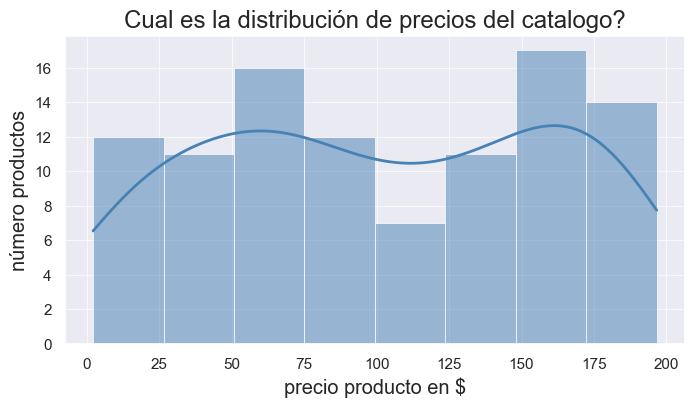

In [129]:
# Para la variable numérica analizo la distribución de precios 
# de los productos del catalogo. Uso histograma 

with sns.axes_style("darkgrid"):

    fig, ax = plt.subplots(figsize=(8,4), dpi=100)

    sns.histplot(
        data=df_products,
        x="price",
        kde=True,
        color="steelblue",
        ax=ax
    )

    ax.set_title("Cual es la distribución de precios del catalogo?")
    ax.set_xlabel("precio producto en $")
    ax.set_ylabel("número productos")

    plt.show()

Interpretación resultado: El resultado de este histograma muestra una distribución bastante uniforme a lo largo de todo el rango de precios.
Esto indica que por lo general tenemos productos en el catalogo de forma equilibrada para todo el rango, con dos rangos que destacan un poco mas con aproximadamente 16 productos (50-75 y 150-175) y un rango de precios central (100-125), que destaca por la poca cantidad de productos que alberga, solo 7 productos. 

#### Dos variables numéricas.

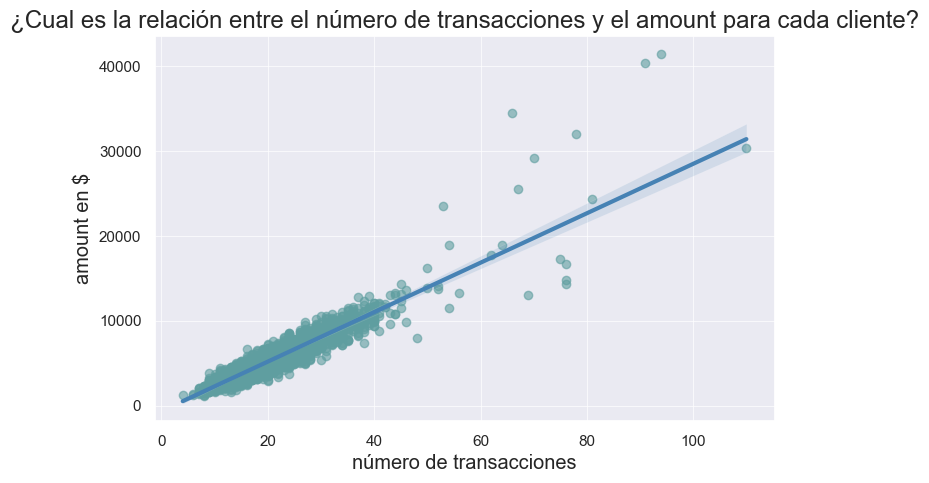

In [102]:
# Voy a analizar 2 variables numéricas calculadas, 
# el volumen de amount por user y el número de transacciones por usuario

ventas_user = (df_transactions.groupby("user_id")[["amount"]].sum()).reset_index()
transacciones_user = (df_transactions.groupby("user_id")[["id"]].count()).reset_index()

df_resumen = ventas_user.merge(transacciones_user, on="user_id")
#df_resumen = df_resumen.rename(columns = {"amount":"ventas", "id":"transacciones"})

with sns.axes_style("darkgrid"):

    fig, ax = plt.subplots(figsize=(8,5), dpi=100)

    sns.regplot(
        data = df_resumen,
        x = "id",
        y = "amount",
        scatter_kws={"alpha":0.6, "color":"cadetblue"},
        line_kws={"color":"steelblue"},
        ax=ax
    )

    ax.set_title("¿Cual es la relación entre el número de transacciones y el amount para cada cliente?")
    ax.set_xlabel("número de transacciones")
    ax.set_ylabel("amount en $")

    plt.show()

Interpretación resultado: El gráfico demuestra claramente que existe una relación directa entre el numero de transacciones que realiza cada usuario y el total amount de cada usuario. Cuantas más transacciones mayor es el amount.

#### Una variable categórica

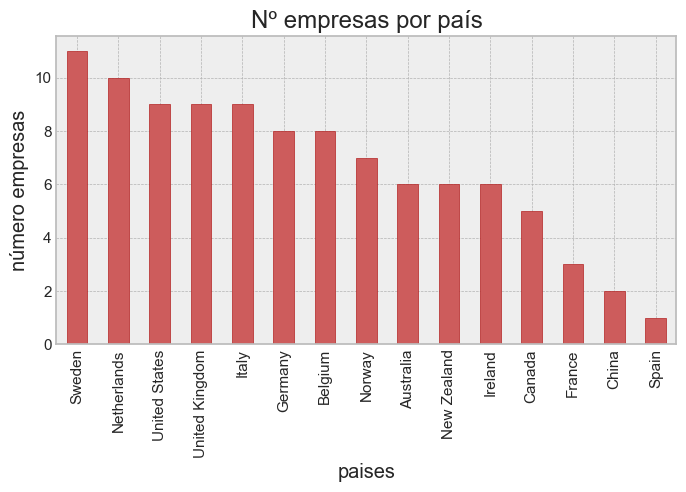

In [103]:
# Para una variable categorica hay varias opciones barras o treemap serian las más recomendables.
# En este caso debido al reducido número de datos a analizar (100) y datos únicos, 
# el gráfico de barras ayudará a mostrar información.

with plt.style.context('bmh'):   # le doy un toque de estilo

    fig, ax = plt.subplots(figsize=(8,4), dpi=100)

    df_companies["country"].value_counts().plot.bar(
        color="indianred",
        edgecolor="firebrick",
        ax=ax
    )

    ax.set_title("Nº empresas por país") # definir título
    ax.set_xlabel("paises") # definir el nombre del eje X
    ax.set_ylabel("número empresas") # definir el nombre del eje Y

    plt.show()

Interpretación resultado: El gráfico muestra que Sweden es el país con mayor número de companies en el marketplace, unas 11 companies, mientras que Spain, China y France son las que menos companies tienen en el marketplace, entre 1 y 3 companies.

#### Una variable categórica y una numérica.

In [104]:
# Cantidad de transacciones por empresa Top 20

# calculo transacciones para cada compañía

df_transaction_company = df_transactions.groupby("company_id").agg(
    num_transacciones=("id" , "count")).sort_values(
        by="num_transacciones", ascending=False).head(20).reset_index()
df_transaction_company

# merge transactio_company con companies para tener nombre

df_merge = df_transaction_company.merge(
    df_companies[["company_id", "company_name"]],
    on = "company_id"
    )

df_merge

,company_id,num_transacciones,company_name
0,b-2222,2401,Ac Fermentum Incorporated
1,b-2302,1599,Nunc Interdum Incorporated
2,b-2330,1593,Donec Fringilla PC
3,b-2366,1586,Mauris Institute
4,b-2614,1585,Rutrum Non Inc.
5,b-2350,1583,Aliquet Vel Vulputate Incorporated
6,b-2566,1576,Aliquam PC
7,b-2574,1567,Orci Adipiscing Limited
8,b-2478,1566,Etiam Bibendum Fermentum Industries
9,b-2550,1564,Auctor Mauris Corp.


In [106]:
import plotly.io as pio
pio.templates


fig = px.bar(df_merge, x='company_name', y='num_transacciones',
             hover_data=['num_transacciones', 'company_id'], 
             #range_y=(1000, 2500),
             range_color=(1500, 1700),
             color='num_transacciones',
             color_continuous_scale='Peach',
             template = 'seaborn',
             labels={'num_transacciones':'número transacciones', 'company_name':'compañías'}, 
             height=600,
             width= 1100,
             title="Cual es el número de transacciones realizadas por compañía?"
             )

fig.show()

Interpretación resultado: El gráfico muestra que AC Fermentum es la compañía que lidera el número de transacciones de manera destacada del resto de compañias del Top 20. También podemos decir que exceptuando AC Fermentum, el Top 20 de compañias tienen apenas diferencia, en el computo total de transacciones realizadas en los años de estudio.

#### Dos variables categóricas

In [107]:
# Voy a comparar e intentar encontrar si hay alguna relación entre el país donde viven los usuarios y
#  el país donde se ubica la compañia, la pregunta sería : ¿Los usuarios compran más en compañías de su mismo país?
# haré merge de 3 tablas y usare un heatmap de seaborn para mostrar la dependencia. Usaré también crosstab

companies = df_companies[["company_id","country"]]
users = df_users[["id","country"]]
transacciones = df_transactions[["id", "amount", "user_id", "company_id"]]

df_merge = transacciones.merge(
    companies,
    on = "company_id"
)
transacciones = df_merge.merge(
    users,
    left_on = "user_id",
    right_on = "id"
)

transacciones = transacciones.rename(
    columns = {
        'id_x':'id', 
        'country_x':'country_company', 
        'country_y':'country_user'
    }).drop(columns=['id_y'])

# vamos a hacer el crosstab

cross = pd.crosstab(
    transacciones["country_user"],
    transacciones["country_company"]
)

display(cross)

country_company,Australia,Belgium,Canada,China,France,Germany,Ireland,Italy,Netherlands,New Zealand,Norway,Spain,Sweden,United Kingdom,United States
country_user,,,,,,,,,,,,,,,
Canada,1165,1649,970,422,0,0,1244,0,0,1217,1414,0,0,0,1905
France,0,0,0,0,534,1419,0,1452,1662,0,0,167,1788,1484,0
Germany,0,0,0,0,502,1478,0,1531,1678,0,0,176,1812,1546,0
Italy,0,0,0,0,478,1448,0,1465,1623,0,0,189,1841,1522,0
Netherlands,0,0,0,0,560,1444,0,1602,1731,0,0,177,1848,1599,0
Poland,0,0,0,0,517,1433,0,1434,1537,0,0,162,1725,1466,0
Portugal,0,0,0,0,520,1540,0,1478,1760,0,0,151,1812,1504,0
Spain,0,0,0,0,552,1459,0,1546,1737,0,0,156,1940,1570,0
Sweden,0,0,0,0,473,1370,0,1389,1571,0,0,167,1729,1417,0


In [109]:
# Preparo una crosstab para poder hacer la comparación del heatmap

cross_porcentaje= pd.crosstab(
    transacciones["country_user"],
    transacciones["country_company"],
    normalize= True
) *100

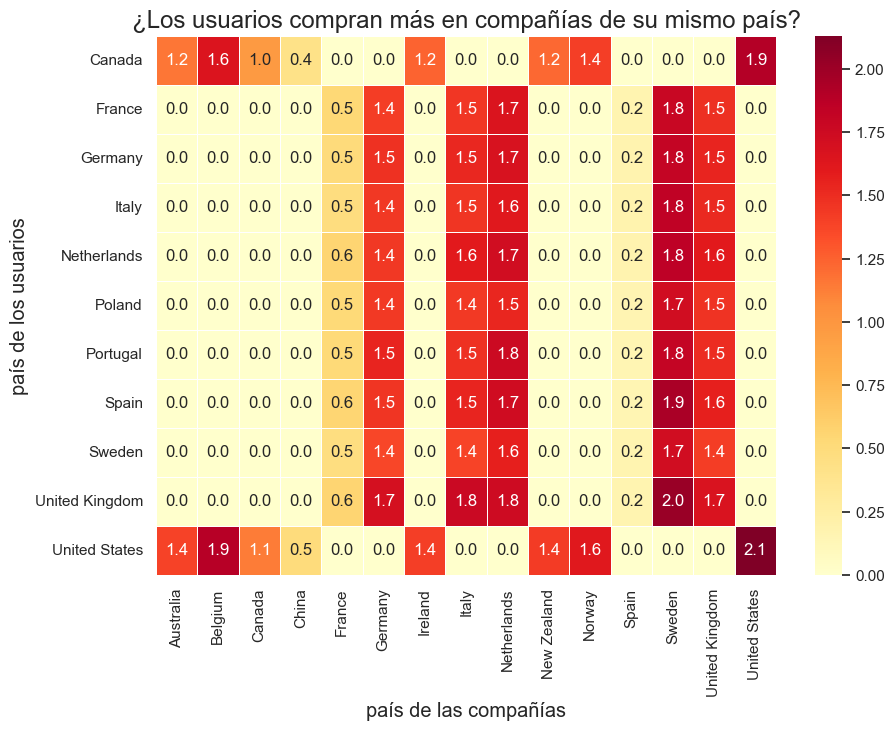

In [110]:
with sns.axes_style("darkgrid"):

    f, ax = plt.subplots(figsize=(10, 7))

    sns.heatmap(
        cross_porcentaje,
        annot=True,
        fmt=".1f",
        linewidths=.5,
        ax=ax,
        cmap="YlOrRd"
    )

    ax.set_title("¿Los usuarios compran más en compañías de su mismo país?")
    ax.set_ylabel("país de los usuarios")
    ax.set_xlabel("país de las compañías")

Interpretación resultado: Según lo que nos muestra el Heatmap podemos afirmar que mayoritariamente no existe una relación directa entre el país del usuario con el echo de que hagan más transacciones con empresas de su país. Hay dos excepciones que son United States y Sweden que si cumplirían la premisa. 

Realmente con este heatmap lo que se aprecia es que los cinco paises con mayor número de transacciones, son donde mayoritariamente compran los usuarios de todos los paises, exceptuando los canadienses y los de United States, donde hay muchos paises que no venden nada por lo que su comportamiento es diferente.

#### Tres variables combinadas

In [111]:
# longitud - latitud - Amount : El amount va a ser la suma de amounts en la misma latitud-longitud geográfica, 
# pero limitada a grados exactos, ya que debido a la alta precision original de este df con 100.000 valores distinto,
# he reducido a grados para unir amounts cercanas en zonas (69 zonas)

df_map = df_transactions[["lat","longitude","amount"]]

df_map["lat"] = df_map["lat"].round(0)
df_map["longitude"] = df_map["longitude"].round(0)

df_map = df_map.groupby(["lat","longitude"])["amount"].sum().reset_index()
display(df_map)

,lat,longitude,amount
0,29.0,-99.0,55693.03
1,29.0,-98.0,249118.26
2,30.0,-95.0,250001.56
3,33.0,-117.0,266480.13
4,33.0,-112.0,292803.44
...,...,...,...
64,60.0,17.0,347131.29
65,60.0,18.0,464864.85
66,60.0,19.0,800017.69
67,61.0,18.0,63060.76


In [ ]:
# Uso scatter_geo de plotly para mostrar las tres cariables "numéricas" en un mapa, 
# la geolocalización y el amount de la zona. El hover o tooltip muestra 
# las 3 magnitudes "lat", "longitude" y "amount".

fig = px.scatter_geo(df_map, 
                     lat='lat',
                     lon='longitude',
                     color="amount", # which column to use to set the color of markers
                     size="amount", # size of markers                                        
                     height=700,
                     width=1200
                     )

fig.update_layout(
    title="Cual es el volumen y distribución geográfica de las transacciones?",
    title_x=0.5
)

fig.update_geos(
    projection_scale=1.2,  # hace el mapa más grande dentro de la figura
    showcountries=True,
    showcoastlines=True
)

fig.show()

Interpretación resultado: El scatter_geo nos muestra que las ventas de las compañías se han limitado a dos continentes determinados, Norte America y Europa. Además podemos distinguir claramente que el volumen de ventas en europa es mucho mayor que en Norte America. 

Además podemos identificar por color y tamaño del punto las ventas acumuladas en una zona concreta de Polonia es el mayor, aunque UK, España, Netherlands y Germany tienen mayor densidad de puntos de gran tamaño. 

Si hacemos analisis por paises, debido al gran numero de paises en Europa, United States y Canada tienen mayores ventas por país aunque mucho más dispersas por territorio.

#### Crea un Pairplot

In [118]:
# Recargo los df_ del diccionario y creo un df_ con todos las columnas que quiero analizar
df_companies = dataframes["companies"]
df_products = dataframes["products"]
df_transaction_product = dataframes["transaction_product"]
df_transactions = dataframes["transactions"]
df_users = dataframes["users"]


In [121]:
# Agregar campo edad a los usuarios (df_users) mediante función age_calc. 
# importo libreria que voy a necesitar
from datetime import date


def age_calc(birth_date):

    today = date.today()

    last_birthday = (
        today.month,
        today.day
    ) >= (
        birth_date.month,
        birth_date.day
    )

    return today.year - birth_date.year - int(not last_birthday)

df_users["Actual_age"] = df_users["birth_date"].apply(age_calc)

display(df_users)

,id,name,surname,phone,email,continent,country,city,postal_code,address,birth_date,Actual_age,full_name
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,America,United States,New York,10001,348-7818 Sagittis St.,1985-11-17,40,Zeus Gamble
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,America,United States,Philadelphia,19101,903 Sit Ave,1992-08-23,33,Garrett Mcconnell
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,America,United States,Houston,77001,736-2063 Tellus St.,1998-04-29,28,Ciaran Harrison
3,4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,America,United States,Phoenix,85001,Ap #545-2244 Erat. Rd.,1989-02-18,37,Howard Stafford
4,5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,America,United States,Philadelphia,19101,341-2821 Ultrices Av.,1998-09-26,27,Hayfa Pierce
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,Busscl,Qishmnuz,+37-135-5556,busscl.qishmnuz@example.com,Europe,Netherlands,Groningen,9711,206 Qishmnuz St,1978-01-26,48,Busscl Qishmnuz
4996,4997,Lfituf,Dazfyjnb,+92-468-5631,lfituf.dazfyjnb@example.com,Europe,Netherlands,Eindhoven,5611,41 Dazfyjnb St,1956-11-12,69,Lfituf Dazfyjnb
4997,4998,Xmjnxt,Uugjkvne,+97-556-4320,xmjnxt.uugjkvne@example.com,Europe,France,Marseille,13001,748 Uugjkvne St,2002-02-27,24,Xmjnxt Uugjkvne
4998,4999,Omjnoy,Rmuqvxgw,+32-354-7682,omjnoy.rmuqvxgw@example.com,America,United States,San Diego,92101,437 Rmuqvxgw St,1996-08-26,29,Omjnoy Rmuqvxgw


In [122]:

df_users["full_name"] = df_users["name"] + " " + df_users["surname"]

users = (
    df_users[["id", "full_name", "Actual_age", "city", "country", "continent" ]]
    .rename(columns={"id": "user_id",
                     "country": "country_user" })
)

companies = (
    df_companies[["company_id", "company_name", "country"]]
    .rename(columns={"country": "country_company"})
)

df_merge = (
    df_transactions[["id", "timestamp", "declined", "amount", "user_id", "company_id", "lat", "longitude"]]
    .merge(companies, on="company_id")
    .merge(users, on="user_id")
)

df_transaction_product = (
    df_transaction_product
    .rename(columns={"transaction_id":"id"})
)

df_products = (
    df_products
    .rename(columns={"id":"product_id"})
    .drop(columns="warehouse_id", errors="ignore")             
)

df_transacciones = (
    df_transaction_product[['id','product_id']]
    .merge(df_merge, on="id", how="left")
    .merge(df_products, on="product_id")
)

display(df_transacciones)

,id,product_id,timestamp,declined,amount,user_id,company_id,lat,longitude,company_name,country_company,full_name,Actual_age,city,country_user,continent,product_name,price,colour,weight
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,2024-08-28 07:16:46,0,395.43,4713,b-2458,46.199929,1.435540,Eget Tincidunt Dui Institute,Netherlands,Gxnmjn Fjycossj,30,Marseille,France,Europe,the duel warden,180.91,#666666,3.0
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26,2024-08-28 07:16:46,0,395.43,4713,b-2458,46.199929,1.435540,Eget Tincidunt Dui Institute,Netherlands,Gxnmjn Fjycossj,30,Marseille,France,Europe,Stark Karstark,53.01,#898989,2.0
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87,2024-08-28 07:16:46,0,395.43,4713,b-2458,46.199929,1.435540,Eget Tincidunt Dui Institute,Netherlands,Gxnmjn Fjycossj,30,Marseille,France,Europe,sith Jade,96.26,#e2e2e2,1.5
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97,2024-08-28 07:16:46,0,395.43,4713,b-2458,46.199929,1.435540,Eget Tincidunt Dui Institute,Netherlands,Gxnmjn Fjycossj,30,Marseille,France,Europe,jinn Winterfell,65.25,#bababa,1.0
4,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,66,2016-12-21 20:07:18,0,155.63,438,b-2370,41.597206,12.221760,Non Justo Corp.,Sweden,Kvkvekp Azofeyj,68,Milan,Italy,Europe,mustafar jinn,2.12,#545454,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253386,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,16,2019-10-30 02:31:37,0,234.22,1008,b-2302,59.332666,18.075323,Nunc Interdum Incorporated,Germany,Securp Faofvqfy,68,Stockholm,Sweden,Europe,the duel warden,180.91,#666666,3.0
253387,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,49,2019-10-30 02:31:37,0,234.22,1008,b-2302,59.332666,18.075323,Nunc Interdum Incorporated,Germany,Securp Faofvqfy,68,Stockholm,Sweden,Europe,the giantsblood maester,53.31,#e2e2e2,1.0
253388,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,18,2023-06-17 19:10:30,0,148.91,680,b-2250,52.063504,4.308616,Amet Nulla Donec Corporation,Italy,Dfrled Vilqcjdl,56,The Hague,Netherlands,Europe,Karstark warden,148.91,#c4c4c4,0.8
253389,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,26,2021-08-05 12:26:24,0,74.54,1103,b-2450,55.638419,-3.616602,Turpis Company,Netherlands,Bmrgli Tprvvmrc,59,Leeds,United Kingdom,Europe,Stark Karstark,53.01,#898989,2.0


In [124]:
# Análisis AOV por usuario

aov_analysis = df_transacciones.groupby(["full_name"]).agg(
    total_amount=("price", "sum"),
    total_trans=("id", "nunique"),
    price_mean=("price", "mean"),
    Actual_age=("Actual_age", "first"),
    country=("country_user", "first"),
    continent=("continent", "first")
).sort_values("total_amount", ascending=False)

aov_analysis["AOV"] = aov_analysis["total_amount"] / aov_analysis["total_trans"]

display(aov_analysis)

,total_amount,total_trans,price_mean,Actual_age,country,continent,AOV
full_name,,,,,,,
Dxwgi Hwcru,41486.54,94,104.500101,49,Germany,Europe,441.346170
Bnyr Astuw,40348.50,91,119.022124,52,Italy,Europe,443.390110
Fwfll Phylgnmhnd,34491.27,66,125.880547,68,Poland,Europe,522.595000
Fqatil Rdwcjcvoa,32016.11,78,130.146789,75,Portugal,Europe,410.462949
Molly Gilliam,30333.03,110,110.704489,32,United Kingdom,Europe,275.754818
...,...,...,...,...,...,...,...
Lamdjb Tiksyzvy,1272.28,8,79.517500,53,United States,America,159.035000
Ajhxsc Episvgwr,1266.63,4,105.552500,32,Italy,Europe,316.657500
Bwtrxj Asmuqvix,1253.18,6,73.716471,20,France,Europe,208.863333


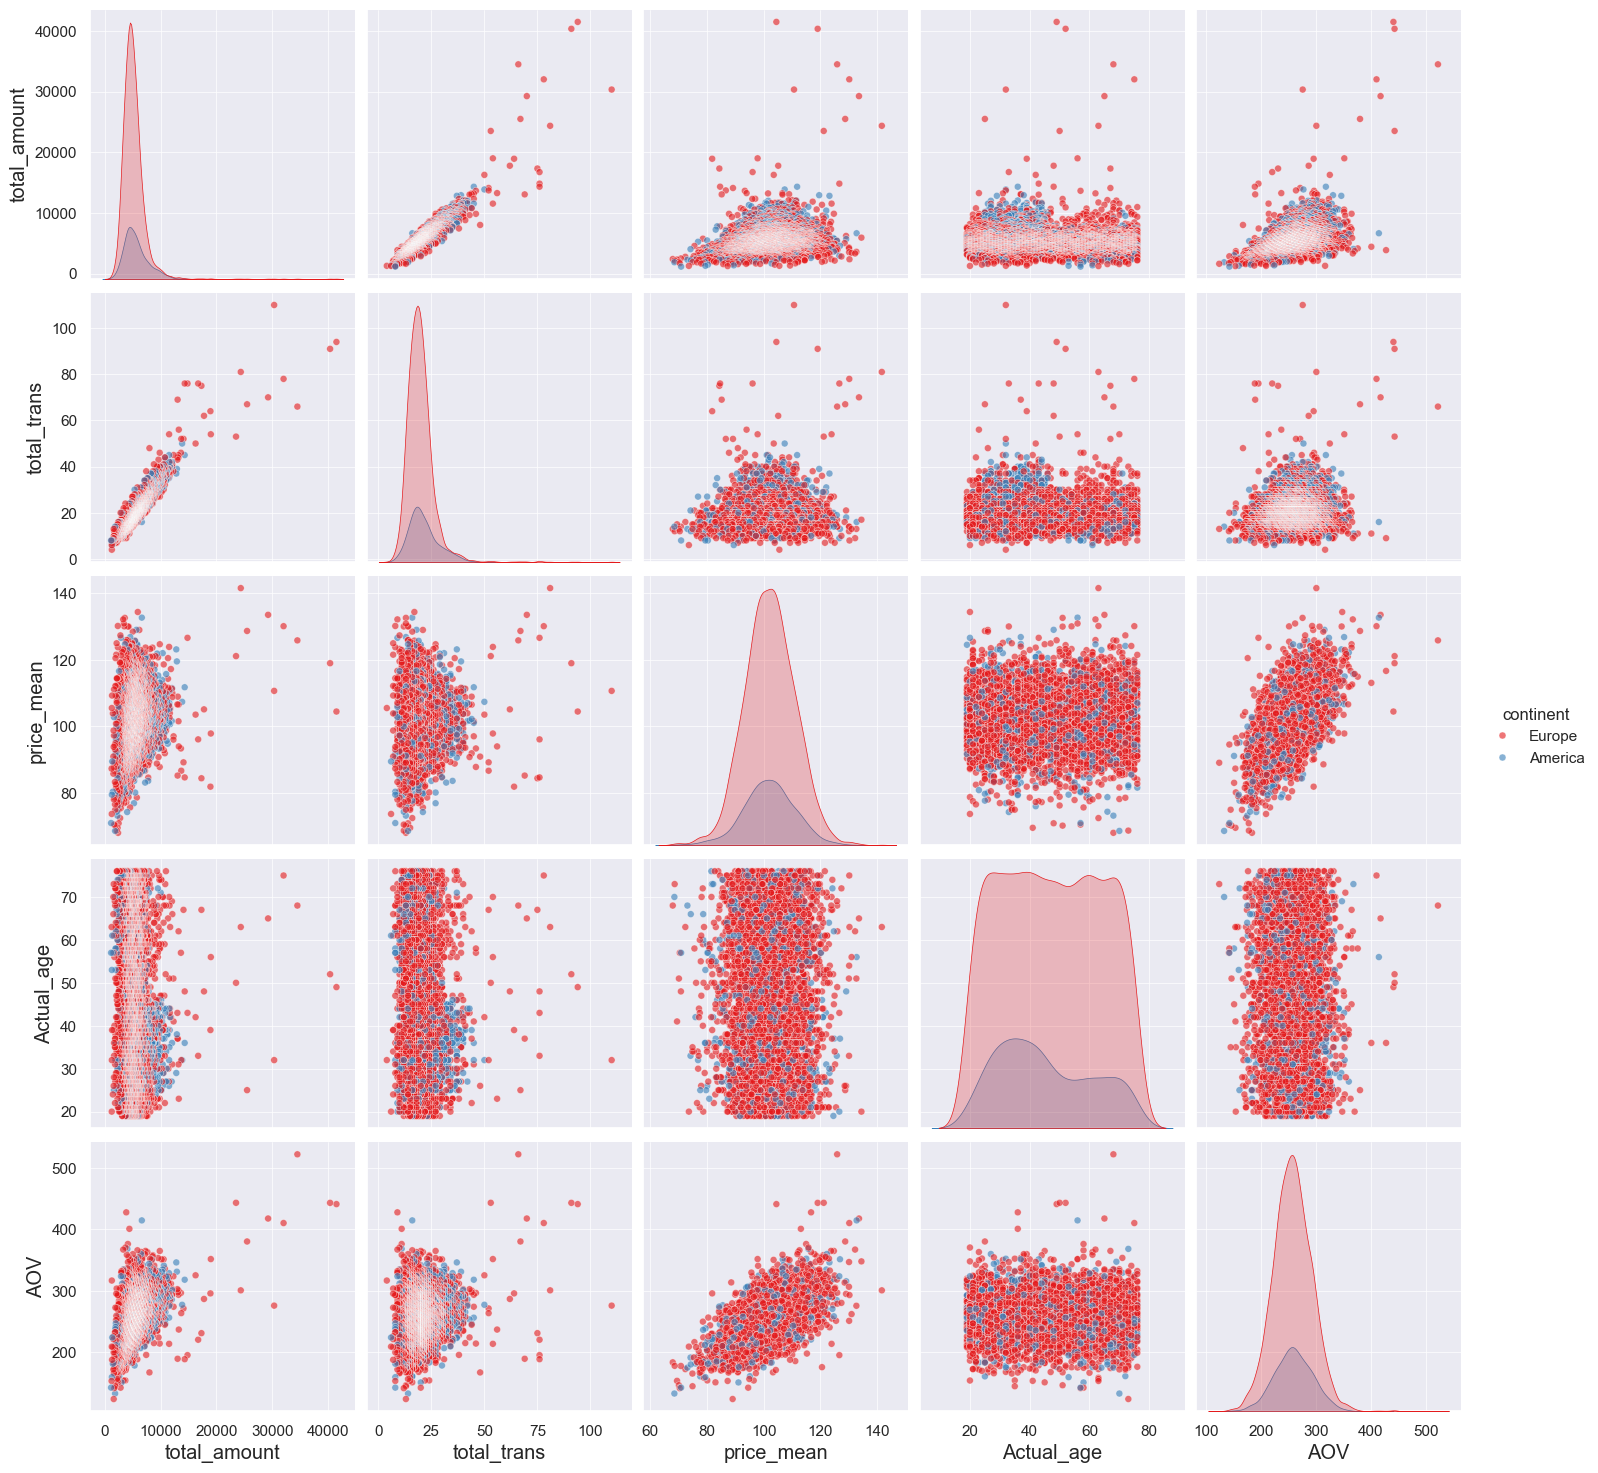

In [125]:
# dibujo el pairplot usando seaborn sobre el df aov_analysis 
# que tiene 5 variables numéricas que quiero analizar

with sns.axes_style("darkgrid"):

    sns.pairplot(
        aov_analysis.reset_index(),
        vars=["total_amount", "total_trans", "price_mean", "Actual_age", "AOV"],
        hue="continent",
        palette="Set1",
        diag_kind="kde",
        height=3,
        plot_kws={
            "alpha": 0.6,
            "s": 25
        }
    );

Interpretación resultado: 

1. Existe una fuerte correlación positiva entre el gasto total (total_amount) y el número de transacciones (total_trans).
2. El AOV aumenta claramente a medida que crece el precio medio de los productos comprados (price_mean).
3. La variable Actual_age no muestra relación significativa con el comportamiento de compra.
4. Europa y América presentan distribuciones y patrones de consumo muy similares en todas las variables analizadas.
5. Se identifican algunos usuarios atípicos con gastos, número de compras y AOV muy superiores al resto.
6. Las distribuciones muestran que la mayoría de usuarios realizan pocas compras y concentran un gasto moderado, mientras que unos pocos acumulan valores muy elevados.

El comportamiento de compra está explicado principalmente por la frecuencia de compra (total_trans) y por el precio medio de los productos adquiridos (price_mean), mientras que variables demográficas como la edad o el continente apenas muestran capacidad para diferenciar patrones de consumo en este conjunto de datos.


![Análisis grafo](<../../Sprint_11_ Visualització_Dades_Python_PowerBI/Sprint_11_Task_S11_01/Captura de pantalla 2026-06-05 a las 10.01.49.png>)

## Nivell 2

### Exercici 1

Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

In [131]:
import numpy as np

#df = aov_analysis[["total_amount", "total_trans"]]

df = aov_analysis[["total_amount", "total_trans", "price_mean", "Actual_age", "AOV"]]

df.corr()

,total_amount,total_trans,price_mean,Actual_age,AOV
total_amount,1.000000,0.919116,0.229280,-0.037126,0.461402
total_trans,0.919116,1.000000,0.032488,-0.042704,0.137459
price_mean,0.229280,0.032488,1.000000,0.004665,0.609162
Actual_age,-0.037126,-0.042704,0.004665,1.000000,-0.021310
AOV,0.461402,0.137459,0.609162,-0.021310,1.000000


In [ ]:
# Voy a usar Plotly que para este grafico me gusta más como queda, en oscuro variables más correlacionados

corr_matrix = df.corr()

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="YlGnBu",
    aspect="auto",
    title="Correlación entre métricas de comportamiento de compra"
)

fig.update_layout(
    title_x=0.5,
    width=850,
    height=700
)

fig.show()

Interpretación del resultado : El comportamiento de compra está explicado principalmente por la frecuencia de transacciones (0,92 vs amount), mientras que el ticket medio depende más del precio de los productos comprados. La edad no parece influir significativamente en los patrones de consumo.

### Exercici 2

Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

In [ ]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species")

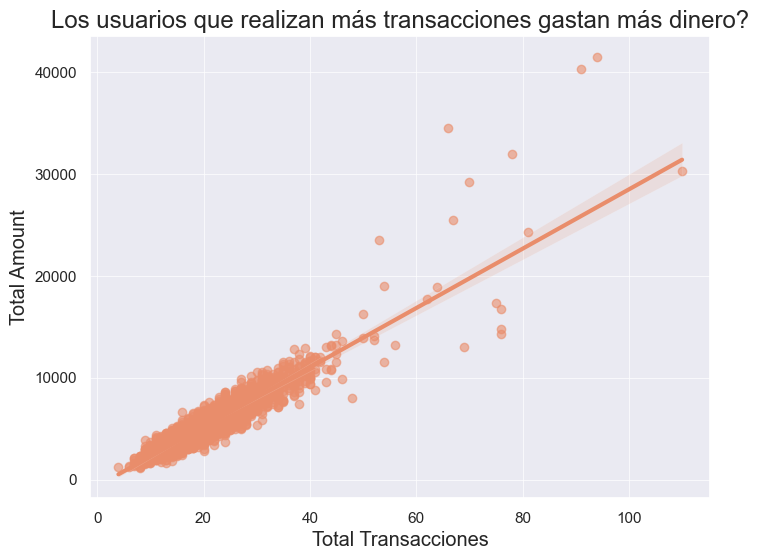

In [128]:
with sns.axes_style("darkgrid"):

    fig, ax = plt.subplots(figsize=(8,6))

    sns.regplot(
        data=aov_analysis,
        x="total_trans",
        y="total_amount $",
        scatter_kws={"alpha":0.6},
        ax=ax
    )

    ax.set_title("Los usuarios que realizan más transacciones gastan más dinero?")
    ax.set_xlabel("Total Transacciones")
    ax.set_ylabel("Total Amount")

    plt.show()